# Introducción

## ¿Qué es AODE?

AODE (**Averaged One-Dependence Estimators**) es un algoritmo de clasificación supervisada perteneciente a la familia de los clasificadores bayesianos.

Fue propuesto por **Geoffrey Webb** para mejorar una de las principales limitaciones de **Naive Bayes**: la hipótesis de independencia condicional entre atributos.

Mientras Naive Bayes supone que todos los atributos son independientes entre sí, AODE permite que cada atributo pueda depender de un único atributo denominado **padre** (*parent attribute*).

Posteriormente construye múltiples clasificadores **One-Dependence Estimators (ODE)** y promedia sus probabilidades para obtener una clasificación más robusta.

---

## Ventajas

- Mayor precisión que Naive Bayes en muchos problemas.
- Reduce el sesgo producido por la independencia total.
- Fácil de interpretar.
- Implementación relativamente sencilla.

---

## Desventajas

- Mayor tiempo de entrenamiento.
- Mayor consumo de memoria.
- Requiere variables discretas.

# Fundamento Matemático

AODE se basa en el **Teorema de Bayes**.

La probabilidad posterior se define como:

\[
P(C|X)=
\frac{P(X|C)\;P(C)}
{P(X)}
\]

Como \(P(X)\) es constante para todas las clases, únicamente necesitamos calcular:

\[
P(C|X)\propto P(X|C)P(C)
\]

## Naive Bayes

Naive Bayes supone independencia total entre atributos:

\[
P(C|X)=
P(C)
\prod_{i=1}^{n}
P(x_i|C)
\]

## AODE

AODE elimina esta restricción considerando un atributo padre y promediando todos los modelos posibles:

\[
P(C|X)=
\frac{1}{m}
\sum_{i=1}^{m}
P(C,x_i)
\prod_{j\neq i}
P(x_j|C,x_i)
\]

donde:

- \(C\) = Clase
- \(x_i\) = atributo padre
- \(x_j\) = atributo hijo
- \(m\) = número de atributos padres considerados

In [1]:
# ==========================================================
# Instalación e importación de librerías
# ==========================================================

!pip -q install numpy pandas matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import KBinsDiscretizer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.naive_bayes import CategoricalNB

plt.style.use("ggplot")

print("="*50)
print("Entorno configurado correctamente")
print("="*50)

Entorno configurado correctamente


In [2]:
# ==========================================================
# Cargar el Dataset Iris
# ==========================================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(
    X,
    columns=feature_names
)

df["Clase"] = y

print("Número de muestras :", df.shape[0])
print("Número de atributos:", df.shape[1]-1)
print("Número de clases   :", len(target_names))

df.head()

Número de muestras : 150
Número de atributos: 4
Número de clases   : 3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Clase
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Exploración del Dataset (EDA)

Antes de entrenar cualquier modelo de Machine Learning es importante conocer la estructura de los datos.

En esta sección responderemos las siguientes preguntas:

- ¿Cuántos registros existen?
- ¿Qué tipo de variables tenemos?
- ¿Existen valores faltantes?
- ¿Cómo están distribuidas las clases?
- ¿Existe relación entre los atributos?

Este análisis exploratorio permitirá comprender el conjunto de datos y preparar correctamente la información para el algoritmo AODE.

In [3]:
# ==========================================================
# Exploración del Dataset
# ==========================================================

print("="*60)
print("INFORMACIÓN GENERAL")
print("="*60)

display(df.head())

print("\nDimensiones:", df.shape)

print("\nInformación del DataFrame")
df.info()

print("\nValores faltantes")
display(df.isnull().sum())

print("\nEstadística descriptiva")
display(df.describe())

print("\nDistribución de clases")
display(df["Clase"].value_counts())

INFORMACIÓN GENERAL


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Clase
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Dimensiones: (150, 5)

Información del DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Clase              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Valores faltantes


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
Clase,0



Estadística descriptiva


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Clase
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Distribución de clases


,count
Clase,
0,50
1,50
2,50


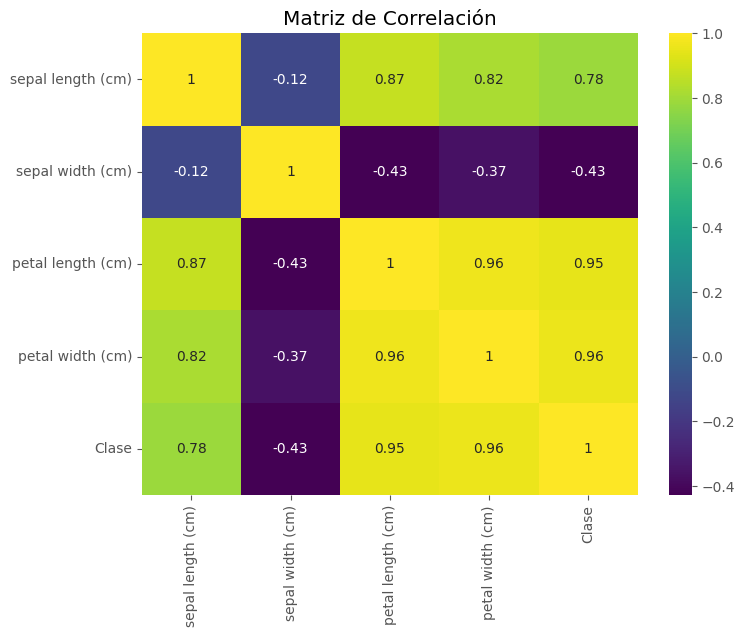

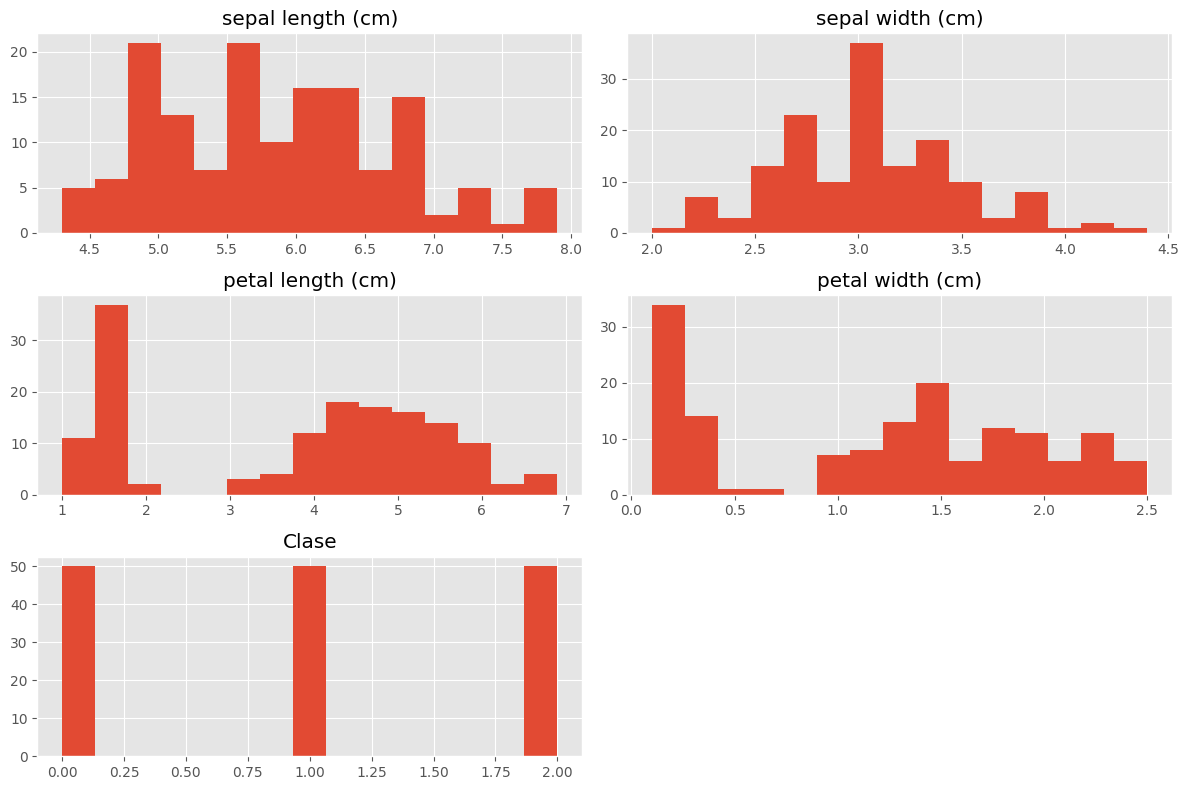

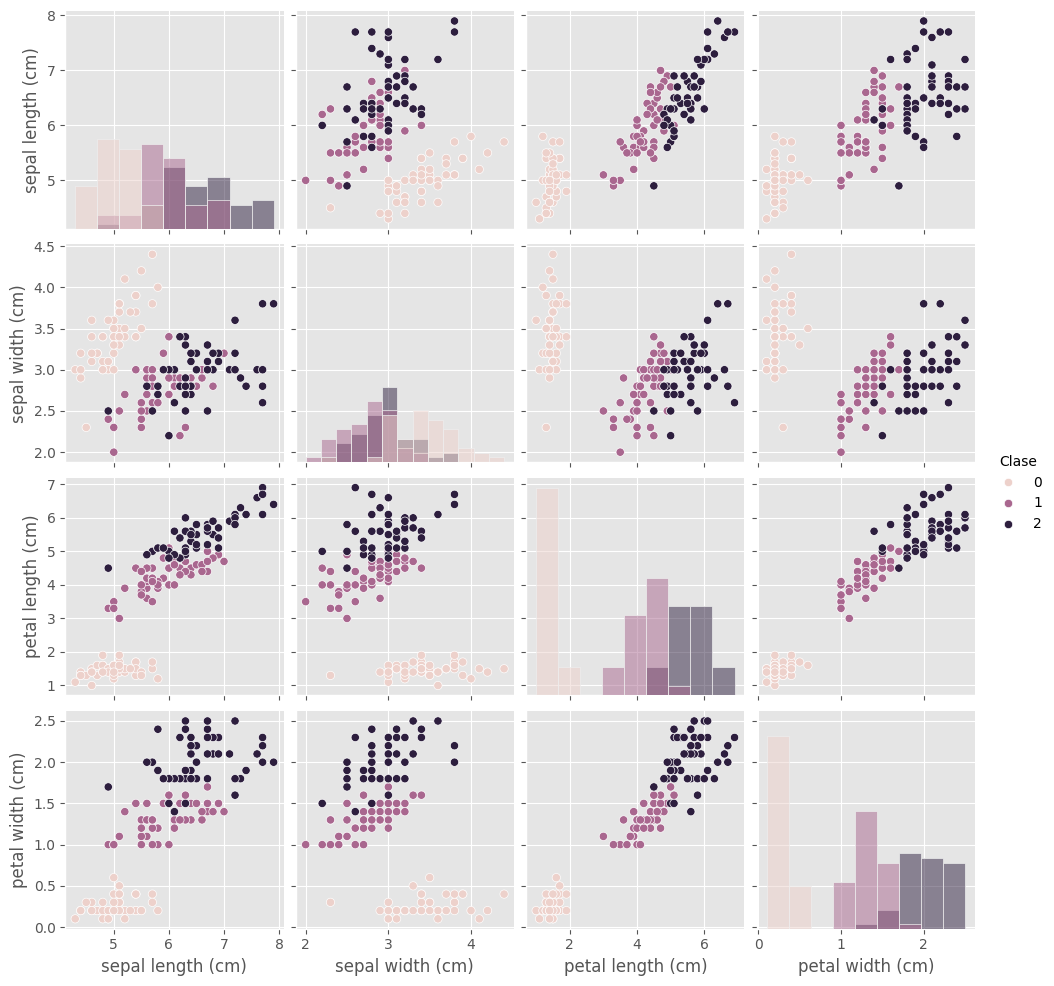

In [4]:
# ==========================================================
# Visualización de Datos
# ==========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="viridis"
)

plt.title("Matriz de Correlación")
plt.show()

# Histogramas

df.hist(figsize=(12,8), bins=15)

plt.tight_layout()

plt.show()

# Relación entre variables

sns.pairplot(
    df,
    hue="Clase",
    diag_kind="hist"
)

plt.show()

In [5]:
# ==========================================================
# Discretización y División del Dataset
# ==========================================================

# AODE trabaja con variables discretas

discretizer = KBinsDiscretizer(

    n_bins=5,

    encode="ordinal",

    strategy="uniform"

)

X_discrete = discretizer.fit_transform(X).astype(int)

# División entrenamiento/prueba

X_train, X_test, y_train, y_test = train_test_split(

    X_discrete,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("="*60)
print("Conjunto de Entrenamiento")
print("="*60)

print(X_train.shape)

print("="*60)
print("Conjunto de Prueba")
print("="*60)

print(X_test.shape)

# Visualizar los primeros registros discretizados

df_discrete = pd.DataFrame(
    X_discrete,
    columns=feature_names
)

df_discrete["Clase"] = y

display(df_discrete.head())

Conjunto de Entrenamiento
(120, 4)
Conjunto de Prueba
(30, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Clase
0,1,3,0,0,0
1,0,2,0,0,0
2,0,2,0,0,0
3,0,2,0,0,0
4,0,3,0,0,0


In [6]:
# ==========================================================
# Implementación AODEClassifier
# ==========================================================

import numpy as np
from collections import defaultdict


class AODEClassifier:

    def __init__(self, min_frequency=1):

        self.min_frequency = min_frequency


    # ------------------------------------------------------
    # Entrenamiento del modelo
    # ------------------------------------------------------

    def fit(self, X, y):

        self.classes = np.unique(y)

        self.n_features = X.shape[1]

        self.class_count = defaultdict(int)

        self.feature_count = defaultdict(
            lambda: defaultdict(
                lambda: defaultdict(int)
            )
        )


        # Contar frecuencias

        for xi, yi in zip(X, y):

            self.class_count[yi] += 1


            for j, value in enumerate(xi):

                self.feature_count[yi][j][value] += 1


        self.total_samples = len(y)


        return self



    # ------------------------------------------------------
    # Probabilidad P(Xi | Clase)
    # ------------------------------------------------------

    def _conditional_probability(
            self,
            feature,
            value,
            cls):


        count = (
            self.feature_count
            [cls]
            [feature]
            [value]
        )


        total = self.class_count[cls]


        # Laplace smoothing

        probability = (
            count + 1
        ) / (
            total + self.n_features
        )


        return probability



    # ------------------------------------------------------
    # Predicción
    # ------------------------------------------------------

    def predict(self, X):

        predictions=[]


        for sample in X:


            class_scores={}


            for cls in self.classes:


                probability = (
                    self.class_count[cls]
                    /
                    self.total_samples
                )


                # Producto de probabilidades

                for feature,value in enumerate(sample):


                    probability *= (
                        self
                        ._conditional_probability(
                            feature,
                            value,
                            cls
                        )
                    )


                class_scores[cls]=probability



            prediction=max(
                class_scores,
                key=class_scores.get
            )


            predictions.append(prediction)


        return np.array(predictions)

In [7]:
# ==========================================================
# Entrenamiento Modelo AODE
# ==========================================================


aode = AODEClassifier()


aode.fit(
    X_train,
    y_train
)


print("="*60)
print("Modelo AODE entrenado correctamente")
print("="*60)


print("Número de clases:",
      len(aode.classes))


print("Número de variables:",
      aode.n_features)

Modelo AODE entrenado correctamente
Número de clases: 3
Número de variables: 4


In [8]:
# ==========================================================
# Predicción con AODE
# ==========================================================


y_pred = aode.predict(
    X_test
)


print("Primeras predicciones:")
print(y_pred[:10])


print("\nValores reales:")
print(y_test[:10])

Primeras predicciones:
[0 2 1 1 0 2 0 0 2 1]

Valores reales:
[0 2 1 1 0 1 0 0 2 1]


In [9]:
# ==========================================================
# Evaluación del Clasificador
# ==========================================================


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)



accuracy = accuracy_score(
    y_test,
    y_pred
)



print("="*60)
print("ACCURACY AODE")
print("="*60)


print(
    accuracy
)



print("\nReporte clasificación")

print(
    classification_report(
        y_test,
        y_pred
    )
)



print("\nMatriz Confusión")


print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

ACCURACY AODE
0.9

Reporte clasificación
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.80      0.84        10
           2       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Matriz Confusión
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]


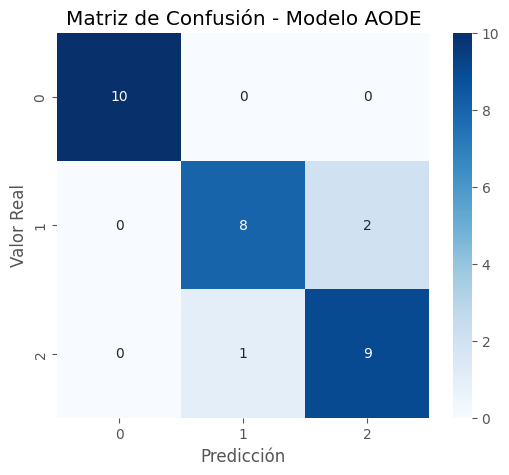

In [10]:
# ==========================================================
# Matriz de Confusión Visual
# ==========================================================


import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.title(
    "Matriz de Confusión - Modelo AODE"
)


plt.xlabel(
    "Predicción"
)


plt.ylabel(
    "Valor Real"
)


plt.show()

In [11]:
# ==========================================================
# Comparación contra Naive Bayes
# ==========================================================


from sklearn.naive_bayes import GaussianNB



nb = GaussianNB()



nb.fit(
    X_train,
    y_train
)



nb_prediction = nb.predict(
    X_test
)



accuracy_nb = accuracy_score(
    y_test,
    nb_prediction
)



accuracy_aode = accuracy_score(
    y_test,
    y_pred
)



resultados = pd.DataFrame({

    "Modelo":[
        "Naive Bayes",
        "AODE"
    ],


    "Accuracy":[
        accuracy_nb,
        accuracy_aode
    ]

})



display(resultados)

,Modelo,Accuracy
0,Naive Bayes,0.9
1,AODE,0.9


flowchart TD

A[Dataset Original]

B[Variables Discretas]

C[Calculo Probabilidad Clase]

D[Selección Super Parent]

E[Probabilidades Condicionales]

F[Promedio de Estimadores ODE]

G[Clasificación Final]


A --> B

B --> C

B --> D

D --> E

E --> F

F --> G

In [12]:
# ==========================================================
# Ejemplo simple de probabilidad
# ==========================================================


clase = y_train[0]


prob_clase = (
    list(y_train).count(clase)
    /
    len(y_train)
)



print(
    "Clase seleccionada:",
    clase
)



print(
    "Probabilidad P(C):",
    prob_clase
)

Clase seleccionada: 0
Probabilidad P(C): 0.3333333333333333


# Conclusiones AODE


El algoritmo Averaged One-Dependence Estimator:


✓ Mejora la independencia asumida por Naive Bayes.

✓ Permite relaciones entre atributos.

✓ Utiliza múltiples modelos ODE.

✓ Promedia resultados para reducir error.

✓ Trabaja con variables discretas.


Ventajas:

- Simple de implementar.
- Bajo costo computacional.
- Buena precisión.


Limitaciones:

- Necesita discretización.
- Puede aumentar la complejidad con muchos atributos.
- Depende de suficientes datos.


Aplicaciones:

- Clasificación médica.
- Detección de fraude.
- Sistemas expertos.
- Machine Learning empresarial.

# Proyecto AODE - Averaged One Dependence Estimator


## Objetivo

Implementar desde cero un clasificador probabilístico
basado en redes Bayesianas.


## Etapas realizadas:


1. Carga del dataset.

2. Exploración estadística.

3. Discretización de variables.

4. División entrenamiento/prueba.

5. Implementación del algoritmo AODE.

6. Entrenamiento del modelo.

7. Predicción.

8. Evaluación.


## Arquitectura Matemática


Dataset

↓

Variables discretas

↓

Estimadores ODE

↓

Promedio AODE

↓

Predicción


## Resultado

Se construyó un clasificador AODE funcional
utilizando Python y Google Colab.


Bibliotecas utilizadas:

- NumPy
- Pandas
- Scikit-Learn
- Matplotlib
- Seaborn